<span style="font-size:30px; color: olive">**Análisis de Medios de formación**</span>

<span style="font-size:14px">***Data source:*** <a href="https://www.mites.gob.es/es/estadisticas/mercado_trabajo/EAL/welcome.htm#">EAL</a></span>

# <span style="font-size:22px; color: orange">**1. Librerias**</span>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# <span style="font-size:22px; color: orange">**2. Carga de datos**</span>

In [4]:
# Cargar datos desde csv del repositorio de datos procesados
data_path="../../Data/processed/EAL_15062026/eal_formacion_unificado_largo.csv"
dataset = pd.read_csv(data_path)
dataset

,anio,tabla,pregunta,ambito,categoria,variable,porcentaje
0,2020,EAL-16,"EMPRESAS, SEGÚN TAMAÑO DE LA EMPRESA, POR COMP...",total_empresas,De dirección,TOTAL,39.910
1,2020,EAL-16,"EMPRESAS, SEGÚN TAMAÑO DE LA EMPRESA, POR COMP...",total_empresas,De trabajo en equipo,TOTAL,58.868
2,2020,EAL-16,"EMPRESAS, SEGÚN TAMAÑO DE LA EMPRESA, POR COMP...",total_empresas,De atención al público/ trato a clientes,TOTAL,49.737
3,2020,EAL-16,"EMPRESAS, SEGÚN TAMAÑO DE LA EMPRESA, POR COMP...",total_empresas,Administrativas de oficina,TOTAL,17.702
4,2020,EAL-16,"EMPRESAS, SEGÚN TAMAÑO DE LA EMPRESA, POR COMP...",total_empresas,Técnicas específicas del puesto de trabajo,TOTAL,23.850
...,...,...,...,...,...,...,...
9898,2024,EAL-25e,EMPRESAS DEL SECTOR SERVICIOS QUE NO PROPORCIO...,La empresa prefirió tener personal con contrat...,NaN,MUCHO,1.792
9899,2024,EAL-25e,EMPRESAS DEL SECTOR SERVICIOS QUE NO PROPORCIO...,El mayor esfuerzo realizado en años anteriores...,NaN,MUCHO,4.502
9900,2024,EAL-25e,EMPRESAS DEL SECTOR SERVICIOS QUE NO PROPORCIO...,La elevada carga de trabajo y el escaso tiempo...,NaN,MUCHO,17.522
9901,2024,EAL-25e,EMPRESAS DEL SECTOR SERVICIOS QUE NO PROPORCIO...,Dificultad para acceder a ayudas o subvencione...,NaN,MUCHO,12.699


In [7]:
medios=dataset[(dataset['tabla']=='EAL-17')]

In [8]:
medios

,anio,tabla,pregunta,ambito,categoria,variable,porcentaje
78,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",total_empresas,TOTAL,TOTAL,100.000
79,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",tamano_empresa,De 5 a 9 trabajadores,TOTAL,100.000
80,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",tamano_empresa,De 10 a 49 trabajadores,TOTAL,100.000
81,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",tamano_empresa,De 50 a 249 trabajadores,TOTAL,100.000
82,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",tamano_empresa,De 250 a 499 trabajadores,TOTAL,100.000
...,...,...,...,...,...,...,...
8043,2024,EAL-17,EMPRESAS SEGÚN SI IMPARTIERON FORMACIÓN POR TA...,ccaa,Madrid (Comunidad de),EMPRESAS QUE NO PROPORCIONAN FORMACIÓN,27.009
8044,2024,EAL-17,EMPRESAS SEGÚN SI IMPARTIERON FORMACIÓN POR TA...,ccaa,Murcia (Región de),EMPRESAS QUE NO PROPORCIONAN FORMACIÓN,23.066
8045,2024,EAL-17,EMPRESAS SEGÚN SI IMPARTIERON FORMACIÓN POR TA...,ccaa,Navarra (Comunidad Foral de),EMPRESAS QUE NO PROPORCIONAN FORMACIÓN,21.157
8046,2024,EAL-17,EMPRESAS SEGÚN SI IMPARTIERON FORMACIÓN POR TA...,ccaa,País Vasco,EMPRESAS QUE NO PROPORCIONAN FORMACIÓN,28.829


## <span style="font-size:18px; color: orange">**2.1 Dividimos el dataset en 3 df independientes**</span>

   - <span style="font-size:14px">**Separamos el dataset en 3 df independientes, uno para `tamaño de empresa`, otro para `actividad económica` y otro para `comunidad autónoma`, para poder hacer un análisis más detallado de cada uno de ellos.**</span>

In [ ]:
medios_tamaño_empresa = medios[(medios['ambito'] == 'total_empresas') | (medios['ambito']=='tamano_empresa')]
medios_sector = medios[medios['ambito'] == 'sector']
medios_comunidad_autonoma = medios[medios['ambito'] == 'ccaa']

In [16]:
print ("="*80)
print ("Información del DataFrame de medios por tamaño de empresa:")
print ("="*80)
medios_tamaño_empresa.info()
print ("="*80)
print ("Información del DataFrame de medios por sector:")
print ("="*80)
medios_sector.info()
print ("="*80)
print ("Información del DataFrame de medios por comunidad autónoma:")
print ("="*80)
medios_comunidad_autonoma.info()

Información del DataFrame de medios por tamaño de empresa:
<class 'pandas.core.frame.DataFrame'>
Index: 180 entries, 78 to 8021
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   anio        180 non-null    int64  
 1   tabla       180 non-null    object 
 2   pregunta    180 non-null    object 
 3   ambito      180 non-null    object 
 4   categoria   180 non-null    object 
 5   variable    180 non-null    object 
 6   porcentaje  180 non-null    float64
dtypes: float64(1), int64(1), object(5)
memory usage: 11.2+ KB
Información del DataFrame de medios por sector:
<class 'pandas.core.frame.DataFrame'>
Index: 270 entries, 84 to 8030
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   anio        270 non-null    int64  
 1   tabla       270 non-null    object 
 2   pregunta    270 non-null    object 
 3   ambito      270 non-null    object 
 4   categori

# <span style="font-size:20px; color: orange">**3. Analizamos según TAMAÑO EMPRESA**</span>

<span style="font-size:14px">Analizamos los medios segun tamaño de la empresa, **filtrando** los datos para quedarnos solo con aquellas empresas que tienen características similares a la nuestra.</span>

In [18]:
medios_tamaño_empresa

,anio,tabla,pregunta,ambito,categoria,variable,porcentaje
78,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",total_empresas,TOTAL,TOTAL,100.000
79,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",tamano_empresa,De 5 a 9 trabajadores,TOTAL,100.000
80,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",tamano_empresa,De 10 a 49 trabajadores,TOTAL,100.000
81,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",tamano_empresa,De 50 a 249 trabajadores,TOTAL,100.000
82,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",tamano_empresa,De 250 a 499 trabajadores,TOTAL,100.000
...,...,...,...,...,...,...,...
8017,2024,EAL-17,EMPRESAS SEGÚN SI IMPARTIERON FORMACIÓN POR TA...,tamano_empresa,De 5 a 9 trabajadores,EMPRESAS QUE NO PROPORCIONAN FORMACIÓN,34.681
8018,2024,EAL-17,EMPRESAS SEGÚN SI IMPARTIERON FORMACIÓN POR TA...,tamano_empresa,De 10 a 49 trabajadores,EMPRESAS QUE NO PROPORCIONAN FORMACIÓN,20.772
8019,2024,EAL-17,EMPRESAS SEGÚN SI IMPARTIERON FORMACIÓN POR TA...,tamano_empresa,De 50 a 249 trabajadores,EMPRESAS QUE NO PROPORCIONAN FORMACIÓN,5.241
8020,2024,EAL-17,EMPRESAS SEGÚN SI IMPARTIERON FORMACIÓN POR TA...,tamano_empresa,De 250 a 499 trabajadores,EMPRESAS QUE NO PROPORCIONAN FORMACIÓN,1.629


In [20]:
#Cuales son nuestras variables y cuantas observaciones tenemos de cada una
medios_tamaño_empresa.groupby('variable').count().sort_values(by='variable', ascending=False)

,anio,tabla,pregunta,ambito,categoria,porcentaje
variable,,,,,,
TOTAL,30,30,30,30,30,30
EMPRESAS QUE PROPORCIONAN FORMACIÓN - TOTAL,30,30,30,30,30,30
EMPRESAS QUE PROPORCIONAN FORMACIÓN - SÓLO OTROS TIPOS DE FORMACIÓN (1),30,30,30,30,30,30
EMPRESAS QUE PROPORCIONAN FORMACIÓN - SÓLO IMPARTICIÓN DE CURSOS (1),30,30,30,30,30,30
EMPRESAS QUE PROPORCIONAN FORMACIÓN - IMPARTICIÓN DE CURSOS Y OTROS TIPOS DE FORMACIÓN (1),30,30,30,30,30,30
EMPRESAS QUE NO PROPORCIONAN FORMACIÓN,30,30,30,30,30,30


In [21]:
#Filtramos por aquellas empresas que tienen caracteristicas similares a la nuestra, es decir, >499 empleados
medios_tamaño_empresa_grandes = medios_tamaño_empresa[medios_tamaño_empresa['categoria']=='Más de 499 trabajadores']
medios_tamaño_empresa_grandes

,anio,tabla,pregunta,ambito,categoria,variable,porcentaje
83,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",tamano_empresa,Más de 499 trabajadores,TOTAL,100.000
115,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",tamano_empresa,Más de 499 trabajadores,EMPRESAS QUE PROPORCIONAN FORMACIÓN - TOTAL,98.119
147,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",tamano_empresa,Más de 499 trabajadores,EMPRESAS QUE PROPORCIONAN FORMACIÓN - IMPARTIC...,90.160
179,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",tamano_empresa,Más de 499 trabajadores,EMPRESAS QUE PROPORCIONAN FORMACIÓN - SÓLO IMP...,8.882
211,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",tamano_empresa,Más de 499 trabajadores,EMPRESAS QUE PROPORCIONAN FORMACIÓN - SÓLO OTR...,0.958
243,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",tamano_empresa,Más de 499 trabajadores,EMPRESAS QUE NO PROPORCIONAN FORMACIÓN,1.881
1697,2021,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",tamano_empresa,Más de 499 trabajadores,TOTAL,100.000
1729,2021,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",tamano_empresa,Más de 499 trabajadores,EMPRESAS QUE PROPORCIONAN FORMACIÓN - TOTAL,97.587
1761,2021,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",tamano_empresa,Más de 499 trabajadores,EMPRESAS QUE PROPORCIONAN FORMACIÓN - IMPARTIC...,86.219
1793,2021,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",tamano_empresa,Más de 499 trabajadores,EMPRESAS QUE PROPORCIONAN FORMACIÓN - SÓLO IMP...,12.160


In [22]:
medios_tamaño_empresa_grandes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30 entries, 83 to 8021
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   anio        30 non-null     int64  
 1   tabla       30 non-null     object 
 2   pregunta    30 non-null     object 
 3   ambito      30 non-null     object 
 4   categoria   30 non-null     object 
 5   variable    30 non-null     object 
 6   porcentaje  30 non-null     float64
dtypes: float64(1), int64(1), object(5)
memory usage: 1.9+ KB


### <span style="font-size:18px; color: rgb(218, 178, 164)">**3.1 Mapeo Jerárquico de variables**</span>

   - <span style="font-size:14px"> 100% empresas del año
├── Empresas que proporcionaron formación
│ ├── Cursos y otros tipos de formación
│ ├── Solo cursos
│ └── Solo otros tipos de formación
└── Empresas que no proporcionaron formación </span>

In [24]:
def clasificar_categoria(variable):
    v = str(variable).strip().upper()

    if v == "TOTAL":
        return "total_anual"
    elif v == "EMPRESAS QUE PROPORCIONAN FORMACIÓN - TOTAL":
        return "si_formacion_total"
    elif "NO PROPORCIONAN FORMACIÓN" in v:
        return "no_formacion"
    elif "SÓLO OTROS TIPOS DE FORMACIÓN" in v:
        return "solo_otros"
    elif "SÓLO IMPARTICIÓN DE CURSOS" in v:
        return "solo_cursos"
    elif "IMPARTICIÓN DE CURSOS Y OTROS TIPOS DE FORMACIÓN" in v:
        return "cursos_y_otros"
    else:
        return "otra"

In [29]:
medios_tamaño_empresa_grandes = medios_tamaño_empresa_grandes.copy()

medios_tamaño_empresa_grandes.loc[:, "categoria_analitica"] = (
    medios_tamaño_empresa_grandes["variable"].apply(clasificar_categoria)
)

cats_validas = [
    "total_anual",
    "si_formacion_total",
    "no_formacion",
    "cursos_y_otros",
    "solo_cursos",
    "solo_otros"
]

df_analisis_empresa = medios_tamaño_empresa_grandes.loc[
    medios_tamaño_empresa_grandes["categoria_analitica"].isin(cats_validas)
].copy()

df_analisis_empresa = df_analisis_empresa.loc[
    :, ["anio", "variable", "categoria_analitica", "porcentaje"]    #Mantenemos 'variable' para comprobar que la categorización es correcta
].sort_values(["anio", "categoria_analitica"])

   - <span style="font-size:14px; color: rgb(144, 170, 38)"> **Generamos una matriz año por categoría analítica**. Esto nos permitirá ver la evolución de cada categoría a lo largo del tiempo y detectar tendencias. </span>

In [30]:
tabla_matriz = (
    df_analisis_empresa
    .pivot_table(
        index="anio",
        columns="categoria_analitica",
        values="porcentaje",
        aggfunc="first"
    )
    .reset_index()
)

tabla_matriz

categoria_analitica,anio,cursos_y_otros,no_formacion,si_formacion_total,solo_cursos,solo_otros,total_anual
0,2020,90.160,1.881,98.119,8.882,0.958,100.0
1,2021,86.219,2.413,97.587,12.160,1.621,100.0
2,2022,90.344,1.298,98.702,8.464,1.192,100.0
3,2023,90.515,0.716,99.284,8.876,0.608,100.0
4,2024,88.305,0.702,99.298,9.742,1.953,100.0


<span style="font-size:14px">Reordenamos las columnas de la matriz para que aparezcan en el orden deseado: `no_formacion`,`si_formacion_total`, `solo_cursos`, `cursos_y_otros`, `solo_otros` y `total_anual`.</span>

In [31]:
# Cambiamos los nombre para adapatarlos a los que queremos
tabla_matriz=tabla_matriz.rename(columns={
    "anio": "Año",
    "no_formacion": "No Formación",
    "si_formacion_total": "Sí Formación (Total)",
    "solo_cursos": "Solo Cursos",
    "cursos_y_otros": "Cursos y Otros",
    "solo_otros": "Solo Otros",
    "total_anual": "Total Anual"
})

tabla_matriz = tabla_matriz.reindex(columns=["Año",
                                             "No Formación",
                                             "Sí Formación (Total)",
                                             "Solo Cursos",
                                             "Cursos y Otros",
                                             "Solo Otros",
                                             "Total Anual"])

tabla_matriz


categoria_analitica,Año,No Formación,Sí Formación (Total),Solo Cursos,Cursos y Otros,Solo Otros,Total Anual
0,2020,1.881,98.119,8.882,90.160,0.958,100.0
1,2021,2.413,97.587,12.160,86.219,1.621,100.0
2,2022,1.298,98.702,8.464,90.344,1.192,100.0
3,2023,0.716,99.284,8.876,90.515,0.608,100.0
4,2024,0.702,99.298,9.742,88.305,1.953,100.0


#### <span style="font-size:18px; color: rgb(228, 204, 123)">**3.1.1 Validamos la jerárquia** </span>

<span style="font-size:14px"> Validamos que la jerarquía de las categorías analíticas sea correcta, es decir, que la suma de las categorías cumpla lo esperado. De este modo, podemos detectar errores en el mapeo de las categorias y datos </span>

In [42]:
#Quiero comprovar que la suma de 'solo cursos + 'cursos y otros' + 'solo otros' = 100 en todos los años
tabla_matriz["Suma Subcategorías"] = (
    tabla_matriz["Solo Cursos"] +
    tabla_matriz["Cursos y Otros"] +
    tabla_matriz["Solo Otros"]
).round()
tabla_matriz

categoria_analitica,Año,No Formación,Sí Formación (Total),Solo Cursos,Cursos y Otros,Solo Otros,Total Anual,Suma Subcategorías
0,2020,1.881,98.119,8.882,90.160,0.958,100.0,100.0
1,2021,2.413,97.587,12.160,86.219,1.621,100.0,100.0
2,2022,1.298,98.702,8.464,90.344,1.192,100.0,100.0
3,2023,0.716,99.284,8.876,90.515,0.608,100.0,100.0
4,2024,0.702,99.298,9.742,88.305,1.953,100.0,100.0


## <span style="font-size:18px; color: orange">**3.2 Calculamos la evolución de cada categoría a lo largo del tiempo**</span>

<span style="font-size:14px;">Calculamos variación absoluta, relativa, índice base 100 y CAGR. Esto nos permite analizar cómo evolucionan las diferentes categorías a lo largo del tiempo.</span>

In [45]:
def calcular_indicadores_serie(s):
    s = s.dropna().sort_index()
    return {
        "valor_inicial": s.iloc[0],
        "valor_final": s.iloc[-1],
        "variacion_absoluta_pp": s.iloc[-1] - s.iloc[0],
        "variacion_relativa_pct": ((s.iloc[-1] 
                                    - s.iloc[0]) / 
                                    s.iloc[0] * 100) 
                                    if s.iloc[0] != 0 
                                    else np.nan,
        "cagr_pct": (((s.iloc[-1]                   #Calculamos el CAGR (Compound Annual Growth Rate) para la serie temporal
                       / s.iloc[0]) ** (1 / (len(s) - 1)) - 1) * 100) 
                       if s.iloc[0] > 0 and len(s) > 1 
                       else np.nan,
        "min": s.min(),
        "max": s.max(),
        "rango": s.max() - s.min(),
        "media_periodo": s.mean(),          #media de los valores de la serie durante el periodo analizado
        "std_periodo": s.std()              #desviación estándar de los valores de la serie durante el periodo analizado
    }


In [46]:
resumen_metricas = pd.DataFrame({
    col: calcular_indicadores_serie(tabla_matriz.set_index("Año")[col])
    for col in [
        "No Formación",
        "Sí Formación (Total)",
        "Solo Cursos",
        "Cursos y Otros",
        "Solo Otros"
    ]
}).T.reset_index().rename(columns={"index": "indicador"})

resumen_metricas.round(3)

,indicador,valor_inicial,valor_final,variacion_absoluta_pp,variacion_relativa_pct,cagr_pct,min,max,rango,media_periodo,std_periodo
0,No Formación,1.881,0.702,-1.179,-62.679,-21.840,0.702,2.413,1.711,1.402,0.745
1,Sí Formación (Total),98.119,99.298,1.179,1.202,0.299,97.587,99.298,1.711,98.598,0.745
2,Solo Cursos,8.882,9.742,0.860,9.683,2.337,8.464,12.160,3.696,9.625,1.492
3,Cursos y Otros,90.160,88.305,-1.855,-2.057,-0.518,86.219,90.515,4.296,89.109,1.844
4,Solo Otros,0.958,1.953,0.995,103.862,19.491,0.608,1.953,1.345,1.266,0.532


<span style="font-size:14px; color: red">**Observación:**</span> <span style="font-size:14px">Entre 2020 y 2024, las empresas de más de 499 trabajadores muestran una consolidación de la cobertura formativa, con descenso de las empresas sin formación y aumento de las que sí forman. Dentro del grupo formador, la ***modalidad mixta sigue siendo mayoritaria***, aunque pierde algo de peso frente a “Solo Cursos” y “Solo Otros</span>

### <span style="font-size:18px; color: orange">**3.2.1 Variación interanual**</span>

<span style="font-size:14px">Calculamos la variación interanual de cada categoría, es decir, la diferencia entre el valor de un año y el valor del año anterior. Esto nos permite ver cómo evolucionan las diferentes categorías de un año a otro. **Nos permite saber si el cambio fue gradual o concentrado en años concretos**</span>

In [47]:
tabla_año = tabla_matriz.copy().sort_values("Año")

cols = [
    "No Formación",
    "Sí Formación (Total)",
    "Solo Cursos",
    "Cursos y Otros",
    "Solo Otros"
]

for col in cols:
    tabla_año[f"{col}_diff_pp"] = tabla_año[col].diff()
    tabla_año[f"{col}_pct_change"] = tabla_año[col].pct_change() * 100

tabla_año.round(3)

categoria_analitica,Año,No Formación,Sí Formación (Total),Solo Cursos,Cursos y Otros,Solo Otros,Total Anual,Suma Subcategorías,No Formación_diff_pp,No Formación_pct_change,Sí Formación (Total)_diff_pp,Sí Formación (Total)_pct_change,Solo Cursos_diff_pp,Solo Cursos_pct_change,Cursos y Otros_diff_pp,Cursos y Otros_pct_change,Solo Otros_diff_pp,Solo Otros_pct_change
0,2020,1.881,98.119,8.882,90.160,0.958,100.0,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021,2.413,97.587,12.160,86.219,1.621,100.0,100.0,0.532,28.283,-0.532,-0.542,3.278,36.906,-3.941,-4.371,0.663,69.207
2,2022,1.298,98.702,8.464,90.344,1.192,100.0,100.0,-1.115,-46.208,1.115,1.143,-3.696,-30.395,4.125,4.784,-0.429,-26.465
3,2023,0.716,99.284,8.876,90.515,0.608,100.0,100.0,-0.582,-44.838,0.582,0.590,0.412,4.868,0.171,0.189,-0.584,-48.993
4,2024,0.702,99.298,9.742,88.305,1.953,100.0,100.0,-0.014,-1.955,0.014,0.014,0.866,9.757,-2.210,-2.442,1.345,221.217


<span style="font-size:14px; color:red">**Observación:** </span><span style="font-size:14px">La evolución interanual muestra una reducción progresiva de las empresas sin formación y un aumento paralelo de las empresas que sí forman. Dentro del grupo formador, las submodalidades presentan variaciones moderadas, con **predominio estable de la formación mixta (Cursos y Otros)**, aunque en 2024 se observa un ligero desplazamiento hacia modalidades más simples o específicas.</span>

## <span style="font-size: 18px; color: orange">**Visualizaciones**</span>

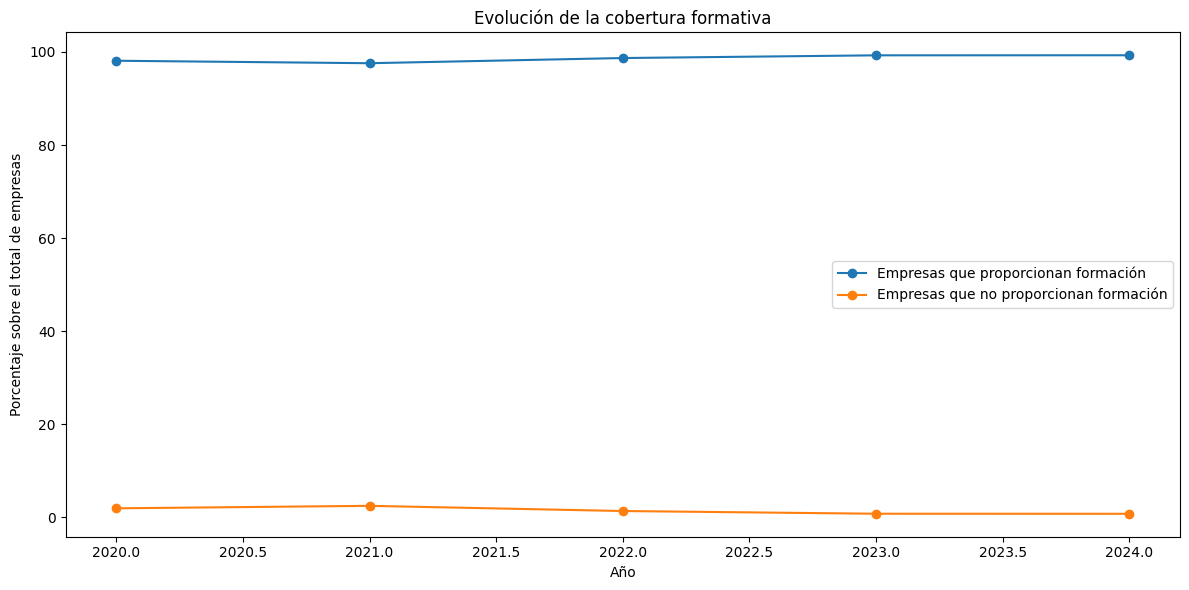

In [48]:
plt.figure(figsize=(12, 6))
plt.plot(tabla_matriz["Año"], tabla_matriz["Sí Formación (Total)"], marker="o", label="Empresas que proporcionan formación")
plt.plot(tabla_matriz["Año"], tabla_matriz["No Formación"], marker="o", label="Empresas que no proporcionan formación")
plt.title("Evolución de la cobertura formativa")
plt.xlabel("Año")
plt.ylabel("Porcentaje sobre el total de empresas")
plt.legend()
plt.tight_layout()
plt.show()

<span style="font-size:16px; color: rgba(92, 234, 186, 0.99)">**Línea temporal de la evolución** de la cobertura formativa y de las modalidades formativas</span>

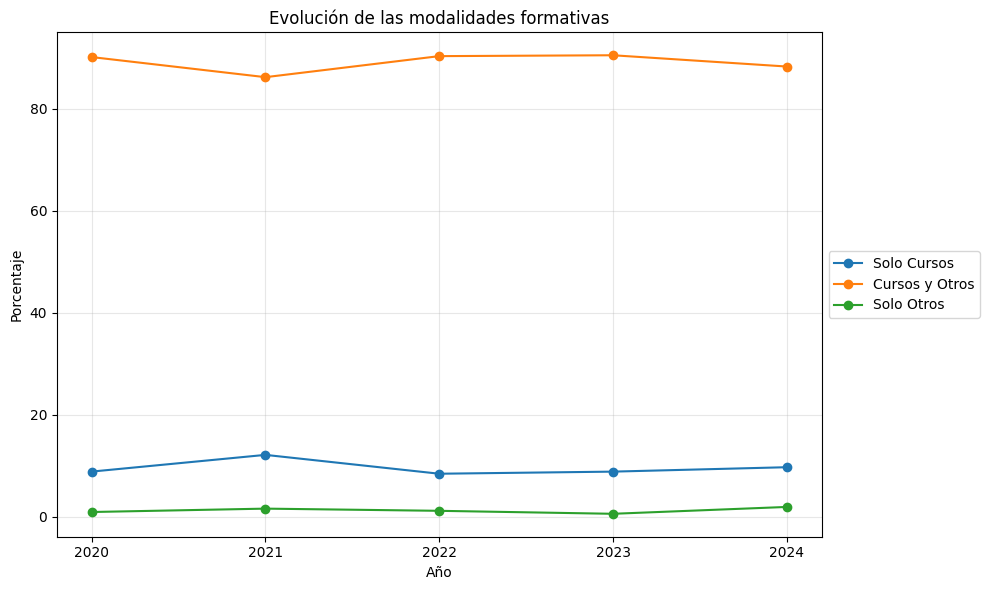

In [50]:
plt.figure(figsize=(10, 6))

plt.plot(tabla_matriz["Año"], tabla_matriz["Solo Cursos"],
         marker="o",
         label="Solo Cursos")
plt.plot(tabla_matriz["Año"], tabla_matriz["Cursos y Otros"],
         marker="o",
         label="Cursos y Otros")
plt.plot(tabla_matriz["Año"], tabla_matriz["Solo Otros"],
         marker="o",
         label="Solo Otros")

plt.title("Evolución de las modalidades formativas")
plt.xlabel("Año")
plt.ylabel("Porcentaje")
plt.xticks(tabla_matriz["Año"].astype(int))

plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))  # leyenda fuera
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<span style="font-size:16px; color: rgba(92, 234, 186, 0.99)">**Barras horizontales**: cambio 2024 vs 2020</span>

   - <span style="font-size:14px; color: rgb(185, 91, 60)">**Por puntos porcentuales (pp)**.</span>

C:\Users\dioul\AppData\Local\Temp\ipykernel_40256\1397552825.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cambio_2024_2020,


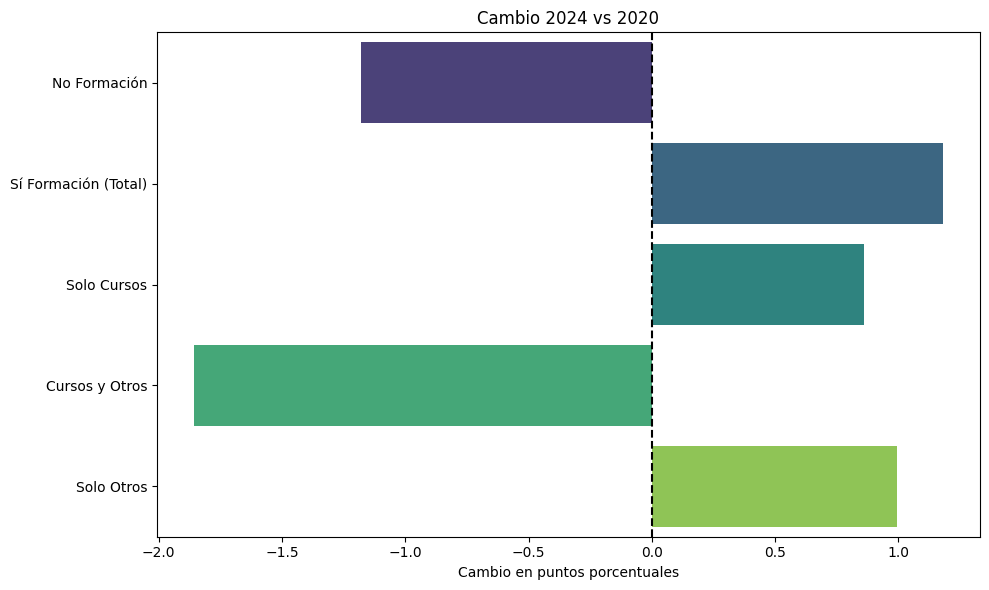

In [52]:
cambio_2024_2020 = pd.DataFrame({
    "indicador": ["No Formación", "Sí Formación (Total)", "Solo Cursos", "Cursos y Otros", "Solo Otros"],
    "cambio_pp": [
        tabla_matriz["No Formación"].iloc[-1] - tabla_matriz["No Formación"].iloc[0],
        tabla_matriz["Sí Formación (Total)"].iloc[-1] - tabla_matriz["Sí Formación (Total)"].iloc[0],
        tabla_matriz["Solo Cursos"].iloc[-1] - tabla_matriz["Solo Cursos"].iloc[0],
        tabla_matriz["Cursos y Otros"].iloc[-1] - tabla_matriz["Cursos y Otros"].iloc[0],
        tabla_matriz["Solo Otros"].iloc[-1] - tabla_matriz["Solo Otros"].iloc[0],
    ]
})

plt.figure(figsize=(10, 6))
sns.barplot(data=cambio_2024_2020,
            x="cambio_pp",
            y="indicador",
            palette="viridis")

plt.axvline(0, color="black", linestyle="--")
plt.title("Cambio 2024 vs 2020")
plt.xlabel("Cambio en puntos porcentuales")
plt.ylabel("")
plt.tight_layout()
plt.show()

   - <span style="font-size:14px; color: rgb(185, 91, 60)">**Por porcentajes relativos (pct)**.</span>

<span style="font-size:16px; color: red">**Ojo con la interpretación del resultado:**</span> <span style="font-size:14px">En nuestro caso, ***Solo Otros*** puede salir con un cambio relativo muy grande porque parte de un valor inicial muy pequeño. Eso no significa necesariamente que sea una categoría dominante; solo que ha crecido mucho en relación con su base inicial.</span>

C:\Users\dioul\AppData\Local\Temp\ipykernel_40256\3965219959.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cambio_2024_2020, x="cambio_relativo_pct", y="indicador", palette="viridis")


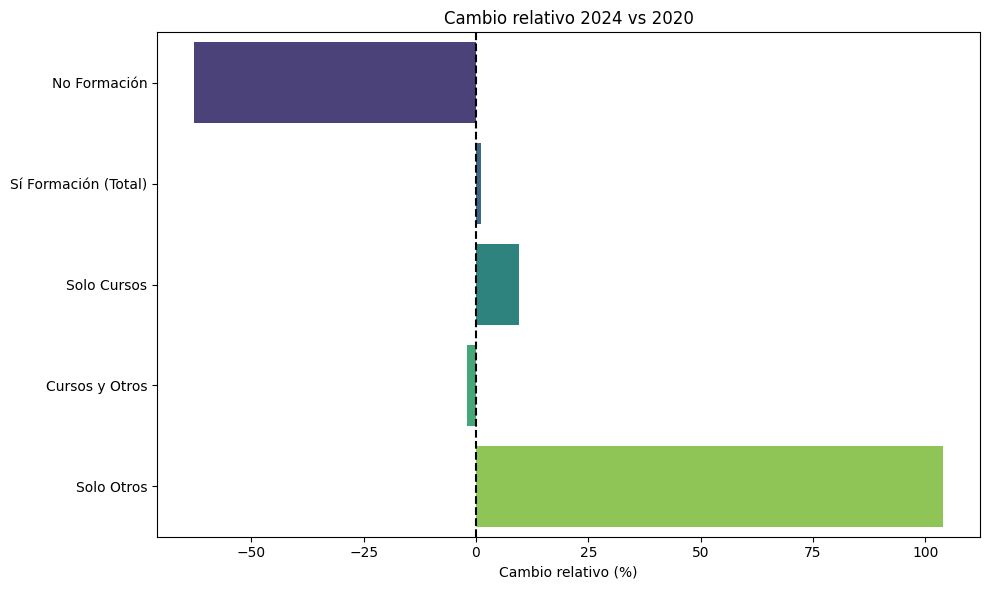

In [53]:
indicadores = ["No Formación", "Sí Formación (Total)", "Solo Cursos", "Cursos y Otros", "Solo Otros"]

cambio_2024_2020 = pd.DataFrame({
    "indicador": indicadores,
    "cambio_relativo_pct": [
        (tabla_matriz[col].iloc[-1] - tabla_matriz[col].iloc[0]) / tabla_matriz[col].iloc[0] * 100
        for col in indicadores
    ]
})

plt.figure(figsize=(10, 6))
sns.barplot(data=cambio_2024_2020, x="cambio_relativo_pct", y="indicador", palette="viridis")
plt.axvline(0, color="black", linestyle="--")
plt.title("Cambio relativo 2024 vs 2020")
plt.xlabel("Cambio relativo (%)")
plt.ylabel("")
plt.tight_layout()
plt.show()

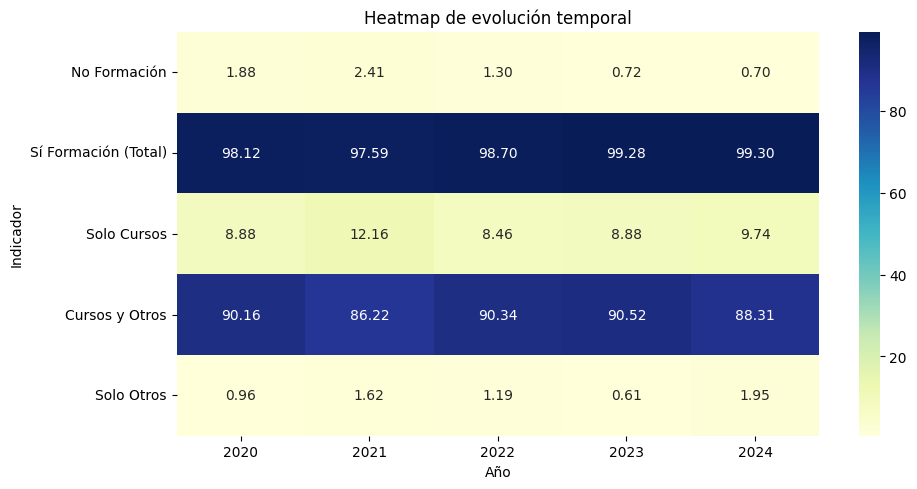

In [54]:
heatmap_df = tabla_matriz.set_index("Año")[
    ["No Formación", "Sí Formación (Total)", "Solo Cursos", "Cursos y Otros", "Solo Otros"]
]

plt.figure(figsize=(10, 5))
sns.heatmap(heatmap_df.T, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Heatmap de evolución temporal")
plt.xlabel("Año")
plt.ylabel("Indicador")
plt.tight_layout()
plt.show()

## <span style="font-size:22px; color: orange">**3.3. Estadística**</span>

### <span style="font-size:18px; color: orange">**3.3.1 Wilcoxon pareado**</span>

   - <span style="font-size:14px; color: rgb(142, 209, 42)">**Solo Cursos vs Cursos y Otros**</span>

<span style="font-size:14px">Solo nos sirve como prueba **exploratoria**, no como evidencia fuerte, porque estamos trabajando con porcentajes agregados y solo 5 años de datos. Sin embargo, nos permite ver si hay diferencias significativas entre las dos modalidades de formación.</span>

<span style="font-size:14px; color: rgb(142, 209, 42)">**Nota:**</span> <span style="font-size:14px">Nos dice si dos series/medios difieren sistemáticamente pero no si una crece en el tiempo</span>

In [55]:
from scipy.stats import wilcoxon
stat, p = wilcoxon(
    tabla_matriz["Cursos y Otros"],
    tabla_matriz["Solo Otros"]
)

print("Estadístico Wilcoxon:", stat)
print("p-valor:", p)

Estadístico Wilcoxon: 0.0
p-valor: 0.0625


In [56]:
stat, p = wilcoxon(
    tabla_matriz["Solo Cursos"],
    tabla_matriz["Solo Otros"]
)

print("Estadístico Wilcoxon:", stat)
print("p-valor:", p)

Estadístico Wilcoxon: 0.0
p-valor: 0.0625


<span style="font-size:14px; color: red">**La prueba de Wilcoxon arroja un estadístico de 0.0 y un p-valor de 0.0625. Aunque el resultado sugiere una tendencia consistente entre las series comparadas, no alcanza significación estadística al 5%, por lo que no se rechaza la hipótesis nula.**</span>

### <span style="font-size:18px; color: orange">**3.3.2 Regresión lineal temporal**</span>

In [59]:
from sklearn.linear_model import LinearRegression
import numpy as np

def tendencia_lineal(df, columna):
    X = df[["Año"]]
    y = df[columna]

    modelo = LinearRegression()
    modelo.fit(X, y)

    pendiente = modelo.coef_[0]
    intercepto = modelo.intercept_
    r2 = modelo.score(X, y)
    pred = modelo.predict(X)

    print(f"\nVariable: {columna}")
    print(f"Pendiente anual: {pendiente:.4f}")
    print(f"Intercepto: {intercepto:.4f}")
    print(f"R²: {r2:.4f}")

    plt.figure(figsize=(8, 5))
    plt.plot(df["Año"], y, marker="o", label="Valor real")
    plt.plot(df["Año"], pred,
             linestyle="--",
             label="Tendencia lineal")
    plt.title(f"Tendencia temporal - {columna}")
    plt.xlabel("Año")
    plt.ylabel("Porcentaje")
    plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
    plt.xticks(tabla_matriz["Año"].astype(int))
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


Variable: No Formación
Pendiente anual: -0.4055
Intercepto: 821.3230
R²: 0.7397


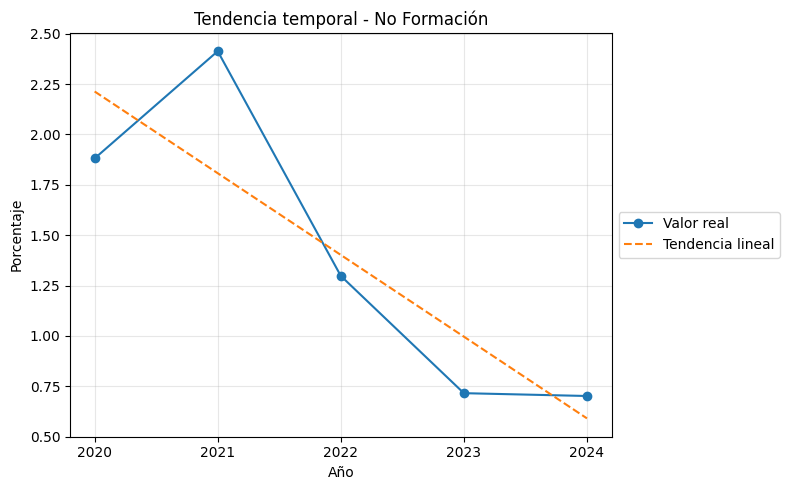


Variable: Sí Formación (Total)
Pendiente anual: 0.4055
Intercepto: -721.3230
R²: 0.7397


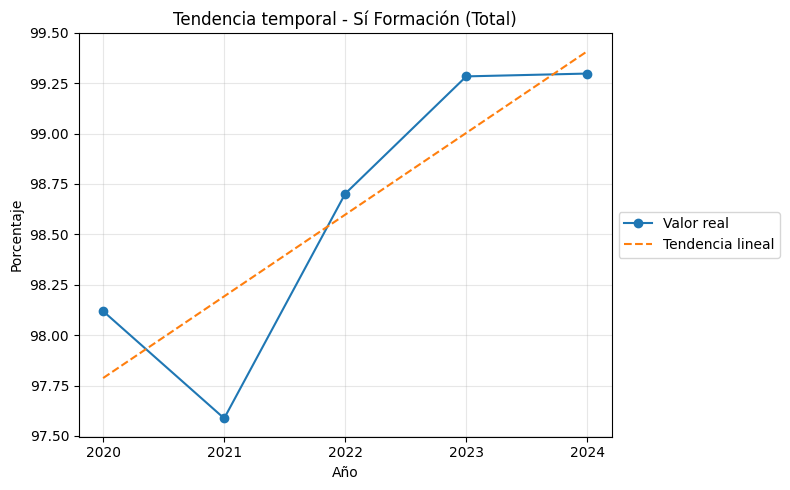


Variable: Solo Cursos
Pendiente anual: -0.1564
Intercepto: 325.8656
R²: 0.0275


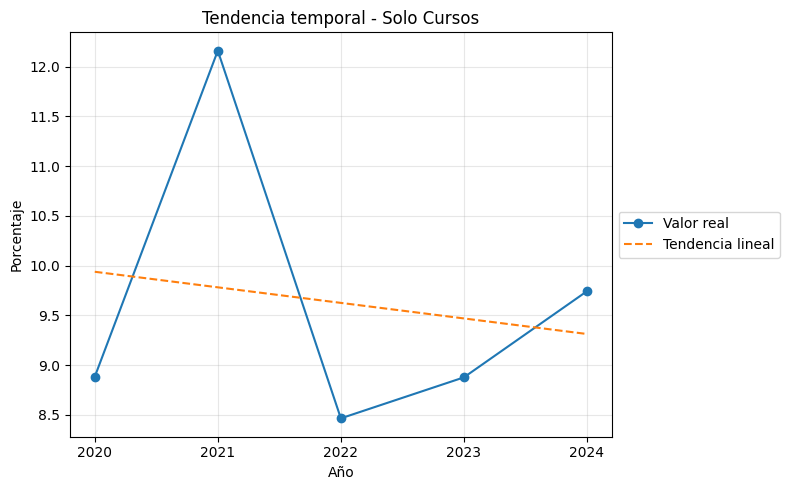


Variable: Cursos y Otros
Pendiente anual: 0.0586
Intercepto: -29.3806
R²: 0.0025


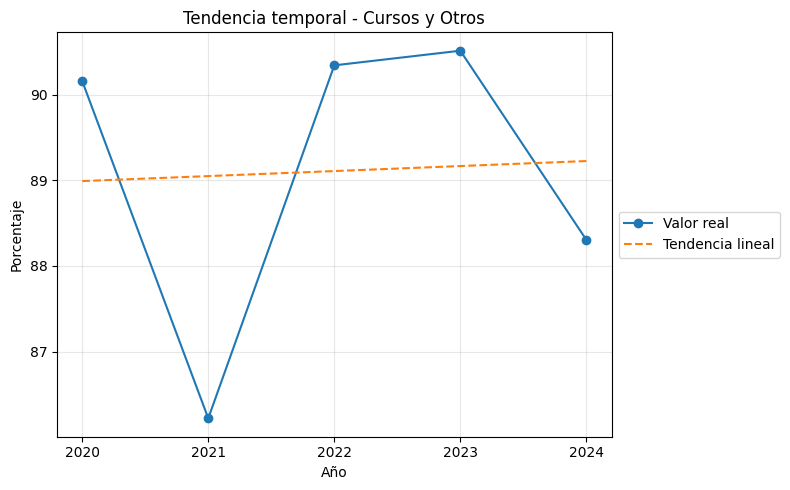


Variable: Solo Otros
Pendiente anual: 0.0977
Intercepto: -196.2830
R²: 0.0844


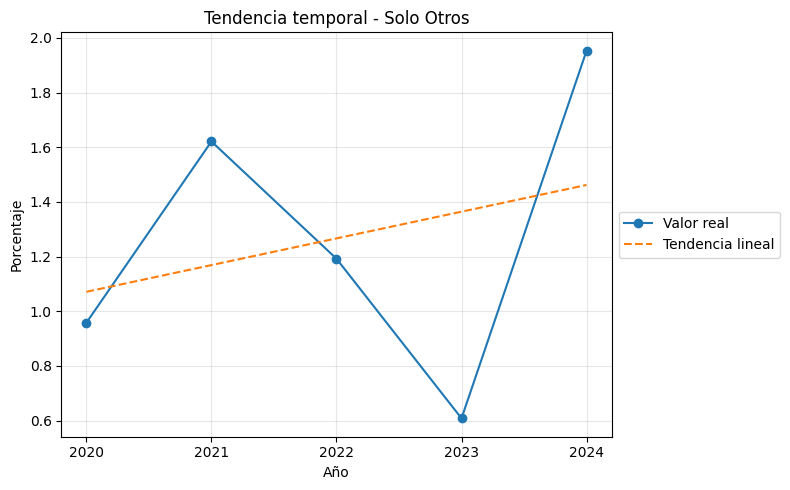

In [60]:
for col in ["No Formación", "Sí Formación (Total)", "Solo Cursos", "Cursos y Otros", "Solo Otros"]:
    tendencia_lineal(tabla_matriz, col)

In [62]:
resultados_tendencia = []

for col in ["No Formación", "Sí Formación (Total)", "Solo Cursos", "Cursos y Otros", "Solo Otros"]:
    X = tabla_matriz[["Año"]]
    y = tabla_matriz[col]

    modelo = LinearRegression()
    modelo.fit(X, y)

    resultados_tendencia.append({
        "indicador": col,
        "pendiente_anual": modelo.coef_[0],
        "intercepto": modelo.intercept_,
        "r2": modelo.score(X, y)
    })

resumen_tendencias = pd.DataFrame(resultados_tendencia)
print(resumen_tendencias.round(4))

              indicador  pendiente_anual  intercepto      r2
0          No Formación          -0.4055    821.3230  0.7397
1  Sí Formación (Total)           0.4055   -721.3230  0.7397
2           Solo Cursos          -0.1564    325.8656  0.0275
3        Cursos y Otros           0.0586    -29.3806  0.0025
4            Solo Otros           0.0977   -196.2830  0.0844


<span style="font-size:16px; color: red">**Interpretación rápida**</span>

   - <span style="font-size:14px"> Si la pendiente es positiva, la variable tiende a subir con los años.</span>

   - <span style="font-size:14px"> Si la pendiente es negativa, tiende a bajar.

   - <span style="font-size:14px"> Si el R² es alto, la recta describe bastante bien la trayectoria observada.

   - <span style="font-size:14px"> Si el R² es bajo, la serie fluctúa más y la tendencia lineal representa peor los datos

# <span style="font-size:22px; color: orange">**4. Análisis de SECTOR**</span>

In [64]:
medios_sector

,anio,tabla,pregunta,ambito,categoria,variable,porcentaje
84,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",sector,Industria,TOTAL,100.000
85,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",sector,Construcción,TOTAL,100.000
86,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",sector,Comercio y reparación de vehículos,TOTAL,100.000
87,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",sector,Transporte y almacenamiento,TOTAL,100.000
88,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",sector,Hostelería,TOTAL,100.000
...,...,...,...,...,...,...,...
8026,2024,EAL-17,EMPRESAS SEGÚN SI IMPARTIERON FORMACIÓN POR TA...,sector,Hostelería,EMPRESAS QUE NO PROPORCIONAN FORMACIÓN,39.265
8027,2024,EAL-17,EMPRESAS SEGÚN SI IMPARTIERON FORMACIÓN POR TA...,sector,"Información, comunicaciones, actividades finan...",EMPRESAS QUE NO PROPORCIONAN FORMACIÓN,19.456
8028,2024,EAL-17,EMPRESAS SEGÚN SI IMPARTIERON FORMACIÓN POR TA...,sector,"Actividades profesionales, científicas y técnicas",EMPRESAS QUE NO PROPORCIONAN FORMACIÓN,18.212
8029,2024,EAL-17,EMPRESAS SEGÚN SI IMPARTIERON FORMACIÓN POR TA...,sector,Actividades administrativas y servicios auxili...,EMPRESAS QUE NO PROPORCIONAN FORMACIÓN,25.739


In [65]:
medios_sector.groupby('categoria').count().sort_values(by='categoria', ascending=False)

,anio,tabla,pregunta,ambito,variable,porcentaje
categoria,,,,,,
Transporte y almacenamiento,30,30,30,30,30,30
"Información, comunicaciones, actividades financieras, de seguros e inmobiliarias",30,30,30,30,30,30
Industria,30,30,30,30,30,30
Hostelería,30,30,30,30,30,30
Construcción,30,30,30,30,30,30
Comercio y reparación de vehículos,30,30,30,30,30,30
"Actividades profesionales, científicas y técnicas",30,30,30,30,30,30
"Actividades artísticas, recreativas y de entretenimiento y otros servicios",30,30,30,30,30,30
Actividades administrativas y servicios auxiliares,30,30,30,30,30,30


## <span style="font-size:18px; color: orange">**4.1 Agrupamos sector servicios**</span>

<span style="font-size:14px">Agrupamos todos aquellos servicios que no sean `Transporte y almacenamiento` en `Otros servicios` para poder comparar nuestro campo versus los otros del mismo sector. Industria y construcción se mantienen independientes.</span>

In [66]:
def agrupar_sector(cat):
    cat = str(cat).strip().upper()
    
    if cat == "TRANSPORTE Y ALMACENAMIENTO":
        return "Transporte y almacenamiento"
    elif cat == "INDUSTRIA":
        return "Industria"
    elif cat == "CONSTRUCCIÓN":
        return "Construcción"
    else:
        return "Otros Servicios"

In [68]:
medios_sector["sector_agregado"] = medios_sector["categoria"].apply(agrupar_sector)
medios_sector.groupby("sector_agregado").count().sort_values(by="sector_agregado", ascending=False)

C:\Users\dioul\AppData\Local\Temp\ipykernel_40256\1921211039.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  medios_sector["sector_agregado"] = medios_sector["categoria"].apply(agrupar_sector)


,anio,tabla,pregunta,ambito,categoria,variable,porcentaje
sector_agregado,,,,,,,
Transporte y almacenamiento,30,30,30,30,30,30,30
Otros Servicios,180,180,180,180,180,180,180
Industria,30,30,30,30,30,30,30
Construcción,30,30,30,30,30,30,30


## <span style="font-size:18px; color: orange">**4.2 Clasificamos los medios**</span>

In [ ]:
medios_sector["categoria_analitica"] = medios_sector["variable"].apply(clasificar_categoria)
medios_sector

C:\Users\dioul\AppData\Local\Temp\ipykernel_40256\2853225562.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  medios_sector["categoria_analitica"] = medios_sector["variable"].apply(clasificar_categoria)


,anio,tabla,pregunta,ambito,categoria,variable,porcentaje,sector_agregado,categoria_analitica
84,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",sector,Industria,TOTAL,100.000,Industria,total_anual
85,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",sector,Construcción,TOTAL,100.000,Construcción,total_anual
86,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",sector,Comercio y reparación de vehículos,TOTAL,100.000,Otros Servicios,total_anual
87,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",sector,Transporte y almacenamiento,TOTAL,100.000,Transporte y almacenamiento,total_anual
88,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",sector,Hostelería,TOTAL,100.000,Otros Servicios,total_anual
89,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",sector,"Información, comunicaciones, actividades finan...",TOTAL,100.000,Otros Servicios,total_anual
90,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",sector,"Actividades profesionales, científicas y técnicas",TOTAL,100.000,Otros Servicios,total_anual
91,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",sector,Actividades administrativas y servicios auxili...,TOTAL,100.000,Otros Servicios,total_anual
92,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",sector,"Actividades artísticas, recreativas y de entre...",TOTAL,100.000,Otros Servicios,total_anual
116,2020,EAL-17,"EMPRESAS, SEGÚN SI IMPARTIERON FORMACIÓN, POR ...",sector,Industria,EMPRESAS QUE PROPORCIONAN FORMACIÓN - TOTAL,64.707,Industria,si_formacion_total


## <span style="font-size:18px; color: orange">**4.3 Filtramos por las categorías que vamos a analizar**</span>

<span style="font-size:14px">Aprovechamos y cambiamos el nombre de las categorías.</span>

In [70]:
cats_validas = [
    "total_anual",
    "si_formacion_total",
    "no_formacion",
    "cursos_y_otros",
    "solo_cursos",
    "solo_otros"
]

df_sector_analisis = medios_sector.loc[
    medios_sector["categoria_analitica"].isin(cats_validas)
].copy()

df_sector_analisis["categoria_analitica"] = df_sector_analisis["categoria_analitica"].replace({
    "total_anual": "Total Anual",
    "si_formacion_total": "Sí Formación (Total)",
    "no_formacion": "No Formación",
    "cursos_y_otros": "Cursos y Otros",
    "solo_cursos": "Solo Cursos",
    "solo_otros": "Solo Otros"
})

In [72]:
df_sector_analisis.groupby('categoria_analitica').count().sort_values(by='categoria_analitica', ascending=False)

,anio,tabla,pregunta,ambito,categoria,variable,porcentaje,sector_agregado
categoria_analitica,,,,,,,,
Total Anual,45,45,45,45,45,45,45,45
Sí Formación (Total),45,45,45,45,45,45,45,45
Solo Otros,45,45,45,45,45,45,45,45
Solo Cursos,45,45,45,45,45,45,45,45
No Formación,45,45,45,45,45,45,45,45
Cursos y Otros,45,45,45,45,45,45,45,45


## <span style="font-size:18px; color: orange">**4.4 Matriz por año y sector agregado**</span>

<span style="font-size:14px; color: red">**Nota:**</span> <span style="font-size:14px">Usamos <code>aggfunc="mean"</code> porque al agrupar varios sectores dentro de **Otros Servicios** necesitábamos una agregación. Como estamos trabajando con porcentajes agregados de sectores distintos, esa agrupación debe interpretarse como un promedio descriptivo entre sectores agrupados, no como un total poblacional.</span>

In [74]:
tabla_sector_agregado = (
    df_sector_analisis
    .pivot_table(
        index=["anio", "sector_agregado"],
        columns="categoria_analitica",
        values="porcentaje",
        aggfunc="mean"
    )
    .reset_index()
    .rename(columns={"anio": "Año"})
)

tabla_sector_agregado.head()

categoria_analitica,Año,sector_agregado,Cursos y Otros,No Formación,Solo Cursos,Solo Otros,Sí Formación (Total),Total Anual
0,2020,Construcción,64.279000,36.544000,25.044,10.677000,63.456000,100.0
1,2020,Industria,64.553000,35.293000,22.506,12.941000,64.707000,100.0
2,2020,Otros Servicios,62.576333,38.483833,22.347,15.076833,61.516167,100.0
3,2020,Transporte y almacenamiento,66.108000,31.821000,26.779,7.113000,68.179000,100.0
4,2021,Construcción,50.595000,29.372000,35.352,14.053000,70.628000,100.0


In [ ]:
#Reindexamos
tabla_sector_agregado = tabla_sector_agregado.reindex(columns=["sector_agregado","Año",
                                             "No Formación",
                                             "Sí Formación (Total)",
                                             "Solo Cursos",
                                             "Cursos y Otros",
                                             "Solo Otros",
                                             "Total Anual"])

tabla_sector_agregado.head()

categoria_analitica,Año,No Formación,Sí Formación (Total),Solo Cursos,Cursos y Otros,Solo Otros,Total Anual
0,2020,36.544000,63.456000,25.044,64.279000,10.677000,100.0
1,2020,35.293000,64.707000,22.506,64.553000,12.941000,100.0
2,2020,38.483833,61.516167,22.347,62.576333,15.076833,100.0
3,2020,31.821000,68.179000,26.779,66.108000,7.113000,100.0
4,2021,29.372000,70.628000,35.352,50.595000,14.053000,100.0


In [ ]:
tabla_sector_agregado

categoria_analitica,Año,No Formación,Sí Formación (Total),Solo Cursos,Cursos y Otros,Solo Otros,Total Anual
0,2020,36.544000,63.456000,25.044000,64.279000,10.677000,100.0
1,2020,35.293000,64.707000,22.506000,64.553000,12.941000,100.0
2,2020,38.483833,61.516167,22.347000,62.576333,15.076833,100.0
3,2020,31.821000,68.179000,26.779000,66.108000,7.113000,100.0
4,2021,29.372000,70.628000,35.352000,50.595000,14.053000,100.0
5,2021,27.948000,72.052000,24.768000,58.716000,16.516000,100.0
6,2021,32.559500,67.440500,25.561500,58.409667,16.028667,100.0
7,2021,27.013000,72.987000,34.678000,49.706000,15.616000,100.0
8,2022,24.236000,75.764000,26.951000,58.659000,14.390000,100.0
9,2022,27.008000,72.992000,20.965000,66.717000,12.319000,100.0
